# Used Car Price Prediction

### Import Libraries and Modules

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import tensorflow
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

2025-01-13 17:45:36.939947: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-13 17:45:38.955980: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-13 17:45:38.967590: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-13 17:45:45.534949: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Load the Dataset

In [3]:
try:
    cars = pd.read_csv('/usercode/car_purchasing.csv',encoding = "ISO-8859-1")

    print(cars.describe(include='all'))
    print("First 5 columns in the dataset:")
    print(cars.head())

    print('there are ' + str(cars.isnull().sum().sum()) + ' null vals in the dataset')

except:
    print("File Not Found")

       customer name                                    customer e-mail  \
count            500                                                500   
unique           498                                                500   
top             Seth  cubilia.Curae.Phasellus@quisaccumsanconvallis.edu   
freq               2                                                  1   
mean             NaN                                                NaN   
std              NaN                                                NaN   
min              NaN                                                NaN   
25%              NaN                                                NaN   
50%              NaN                                                NaN   
75%              NaN                                                NaN   
max              NaN                                                NaN   

       country      gender         age  annual Salary  credit card debt  \
count      500  500.0000

### Create Pairplots

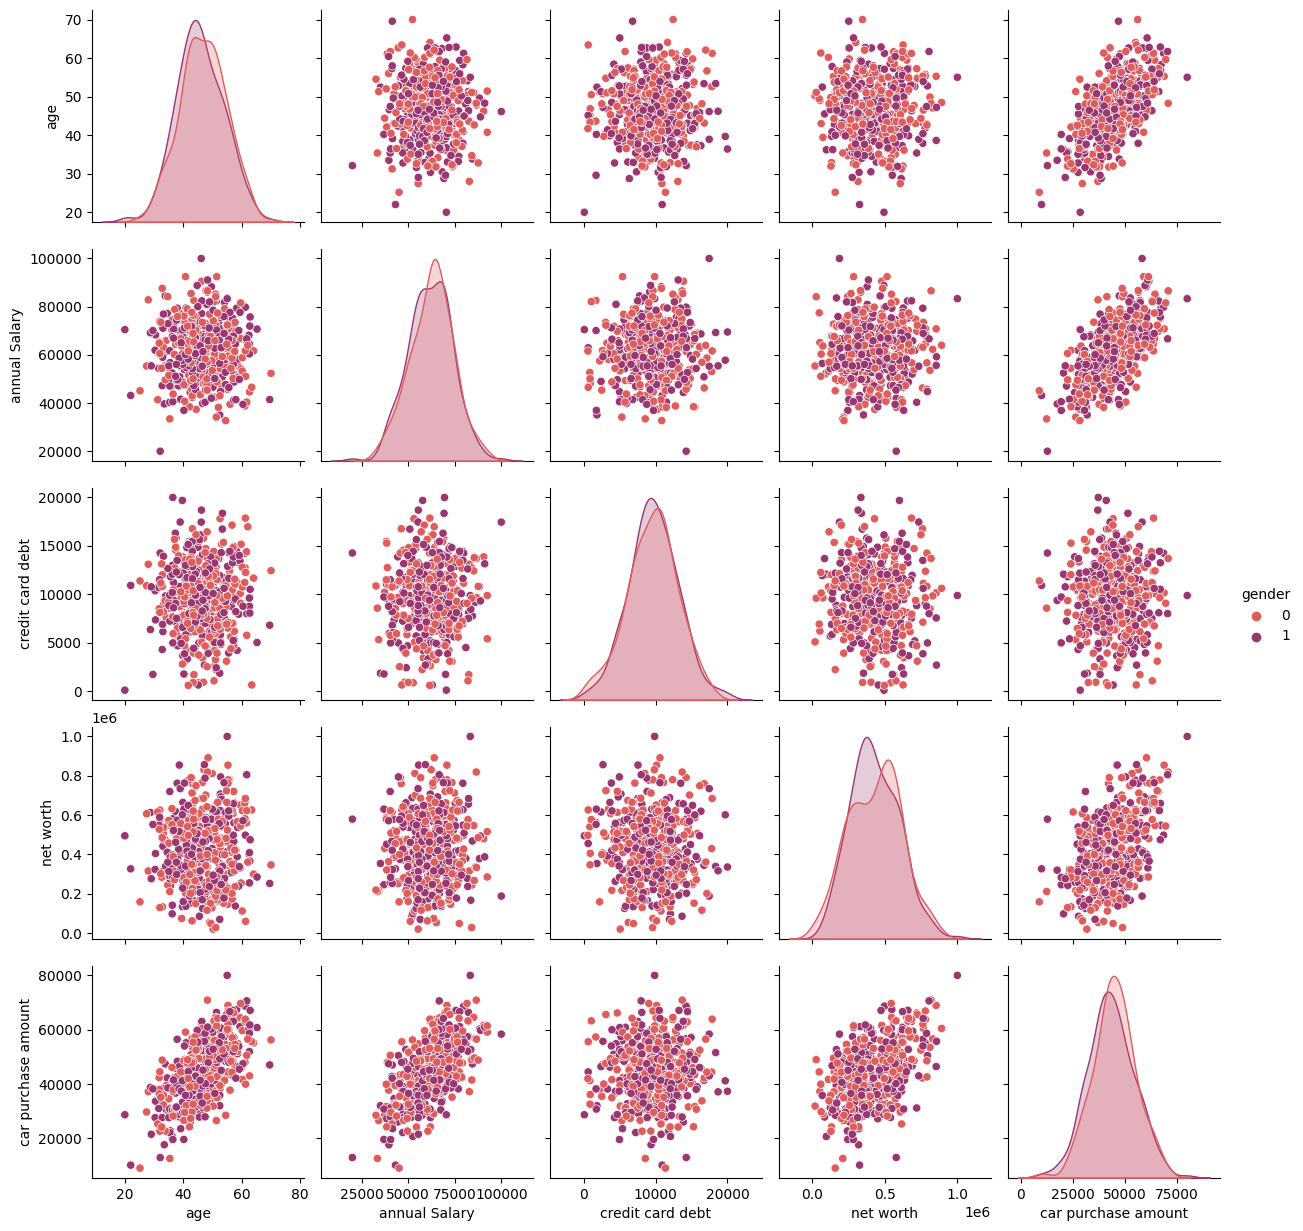

In [4]:
sb.pairplot(cars, hue = "gender", palette = "flare")

### Previous Owner's Net Worth vs Car Purchase Amount Plot

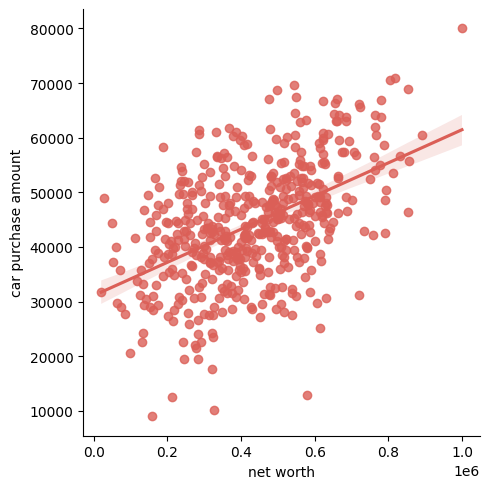

In [8]:
sb.set_palette('hls')
sb.lmplot(data = cars, x = "net worth", y = "car purchase amount")

### Car Owner's Age vs Car Purchasing Amount Plot

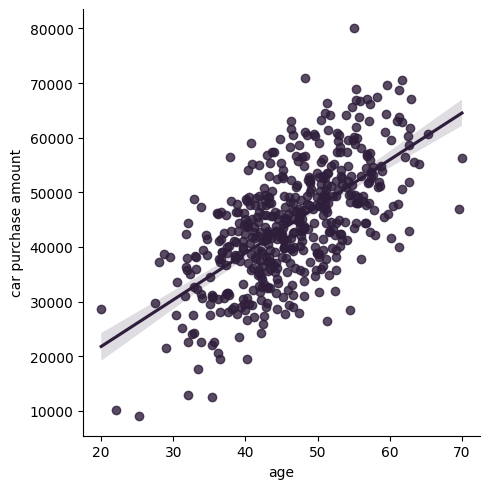

In [9]:
sb.set_palette(sb.color_palette("mako"))
sb.lmplot(data = cars, x = "age", y = "car purchase amount")

### Scatter Plots for Comparative Analysis

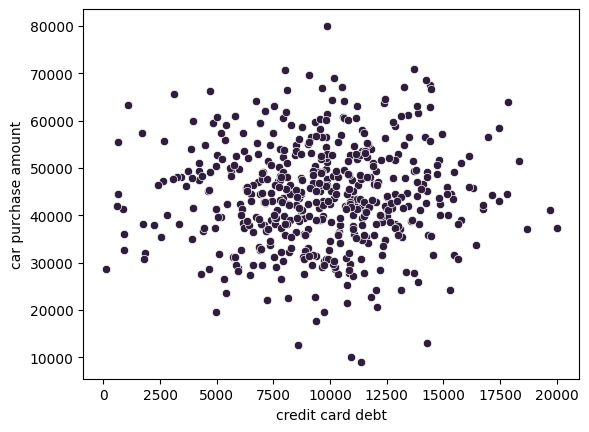

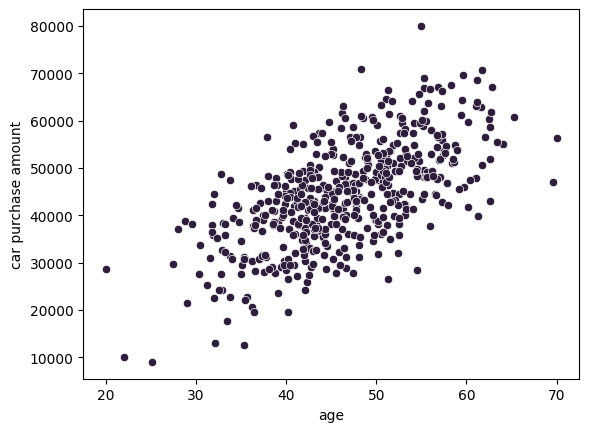

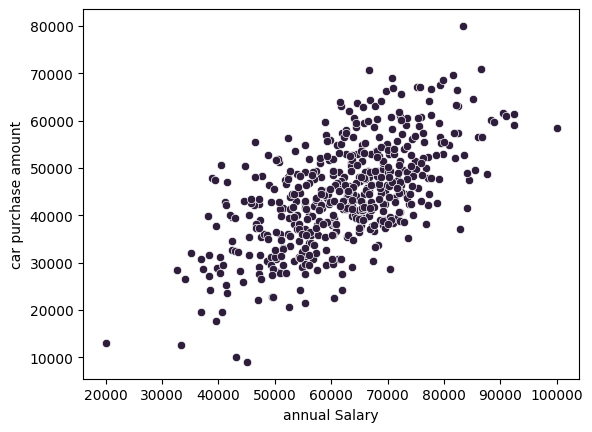

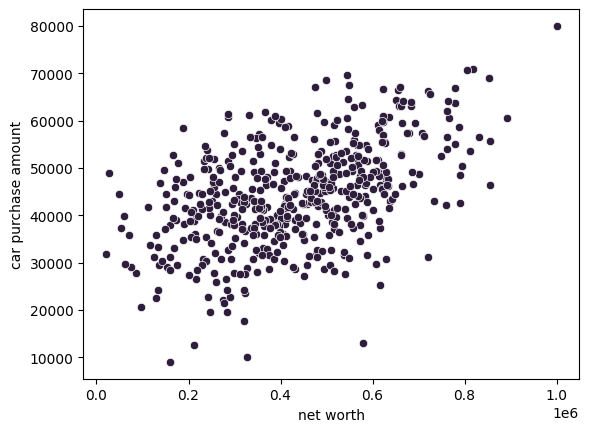

In [10]:
axis_task6 = ['credit card debt', 'age', 'annual Salary', 'net worth']

for i in axis_task6:
    sb.scatterplot(data = cars, x = i, y = "car purchase amount")
    plt.show()

### Create Input and Output Parameters

In [11]:
print(list(cars.columns))

['customer name', 'customer e-mail', 'country', 'gender', 'age', 'annual Salary', 'credit card debt', 'net worth', 'car purchase amount']


In [12]:
#drop unnessecary collumns

cars.drop(columns = ["customer name", "customer e-mail", "gender", "country"], inplace=True)

op = 'car purchase amount'
y = cars[op]
x = cars.drop(op,axis = 1)

print(list(x.columns))

['age', 'annual Salary', 'credit card debt', 'net worth']


### Split the Training and Testing Data

In [13]:
scaler = MinMaxScaler()
x = scaler.fit_transform(x)
y = scaler.fit_transform(y.values.reshape(-1,1))
x_train,x_test,y_train,y_test = train_test_split(x, y, random_state=0, train_size=0.7)

### Build the Model

In [14]:
model = Sequential()
model.add(Dense(64, activation = 'relu', input_dim = 4))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(1,  activation = 'linear'))

model.compile(
    optimizer = 'adam',
    loss = 'mean_squared_error',
    metrics = ['mean_absolute_error']
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,433
Trainable params: 2,433
Non-trainable params: 0
_________________________________________________________________


### Train the Model

In [15]:
training_model = model.fit(x_train,y_train,epochs = 200, validation_split = 0.3, shuffle  = True)

Epoch 1/200
8/8 [==============================] - 2s 36ms/step - loss: 0.1979 - mean_absolute_error: 0.4107 - val_loss: 0.0786 - val_mean_absolute_error: 0.2538
Epoch 2/200
8/8 [==============================] - 0s 10ms/step - loss: 0.0391 - mean_absolute_error: 0.1612 - val_loss: 0.0094 - val_mean_absolute_error: 0.0777
Epoch 3/200
8/8 [==============================] - 0s 9ms/step - loss: 0.0122 - mean_absolute_error: 0.0884 - val_loss: 0.0177 - val_mean_absolute_error: 0.1136
Epoch 4/200
8/8 [==============================] - 0s 9ms/step - loss: 0.0171 - mean_absolute_error: 0.1107 - val_loss: 0.0115 - val_mean_absolute_error: 0.0893
Epoch 5/200
8/8 [==============================] - 0s 9ms/step - loss: 0.0092 - mean_absolute_error: 0.0759 - val_loss: 0.0074 - val_mean_absolute_error: 0.0697
Epoch 6/200
8/8 [==============================] - 0s 9ms/step - loss: 0.0081 - mean_absolute_error: 0.0706 - val_loss: 0.0084 - val_mean_absolute_error: 0.0732
Epoch 7/200
8/8 [===============

### Validate The Model

In [16]:
y_prediction = model.predict(x_test)
prediction_accuracy = r2_score(y_test,y_prediction)
print("Accuracy: ", prediction_accuracy*100,'%')

5/5 [==============================] - 0s 2ms/step
Accuracy:  99.9243245851387 %
